# NEXRAD radar scans

The WSR-88D network of about 160 NEXRAD radars scans the atmosphere
continuously, each radar completing a volume, a stack of conical sweeps at
rising elevations, every four to ten minutes. The raw Level II data, with
reflectivity, radial velocity, and the dual-polarization moments for every
gate, are archived by NOAA and Unidata in the public `unidata-nexrad-level2`
S3 bucket from 1991 on. One file is one radar's one volume.

This walkthrough pulls the KTLX (Oklahoma City) volume that began just after
20:00 UTC on 6 May 2024, hours before that evening's tornadoes, opens its
lowest sweep, and uses the correlation coefficient to tell weather from
everything else the radar sees. It needs `usdata[radar]` and matplotlib,
downloads one file of about 9.6 MB, and runs in a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xradar

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; xradar {xradar.__version__}; xarray {xr.__version__}")

Executed (UTC): 2026-09-24T06:16:21+00:00
usdata 0.26.0; xradar 0.12.0; xarray 2026.7.0


## Select

The manifest names one radar by site id, `KTLX`, and a window of volume start
times, inclusive at both ends: 20:00 to 20:05 UTC on 6 May 2024, which here
holds one volume. A shorter window around a known start selects one volume
exactly; a
geographic query or `nearest` picks radars by position instead of by id.
Windows span at most 31 days, and every file is fetched whole.

In [2]:
print(manifest.read_text())

name: ktlx-one-volume
sources:
  - dataset: noaa:nexrad-level2
    start: 2024-05-06T20:00:00Z
    end: 2024-05-06T20:05:00Z
    params:
      site: KTLX



## What arrives

One Level II archive file, named for the radar and the volume's start time.
The first pull writes `dataset.lock.json` beside the manifest, pinning the
file's checksum; later pulls reuse the pin and the cache.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)
print("Volume start:", item.asset.time.start.isoformat())

File: KTLX20240506_200116_V06
Bytes: 9622867
Source: s3://unidata-nexrad-level2/2024/05/06/KTLX/KTLX20240506_200116_V06
Retrieved (UTC): 2026-09-24T06:16:22+00:00
Checksum: sha256:de5bd64281fc57fcb3c4c4a071722221bc3d1515c5e766462178434f2c065b2c
Volume start: 2024-05-06T20:01:16+00:00


## Open

The radar reader decodes with [xradar](https://docs.openradarscience.org/projects/xradar/)
and returns an xarray DataTree: the root holds the radar's position and the
volume's metadata, and each sweep is a node. `sweep=0` decodes only the
lowest sweep, which keeps memory to tens of megabytes rather than the whole
volume's hundreds. Each moment is an `(azimuth, range)` array: azimuth in
degrees clockwise from north, range in metres along the beam. Below-threshold
and range-folded gates are NaN, and every ray carries its own UTC time.

In [4]:
radar = item.open(sweep=0)
sweep = radar["/sweep_0"].to_dataset()
moments = [name for name, data in sweep.data_vars.items() if "range" in data.dims]
print(
    "Radar:",
    radar.attrs["instrument_name"],
    f"at {float(radar['latitude']):.3f} °N,",
    f"{float(radar['longitude']):.3f} °E",
)
print("Elevation cuts in the volume:", radar.attrs["actual_elevation_cuts"])
print(f"Sweep 0: {float(sweep.sweep_fixed_angle):.2f}° elevation,", dict(sweep.sizes))
print(f"Range: {float(sweep.range.min()) / 1000:.1f} to {float(sweep.range.max()) / 1000:.1f} km")
print("Ray times:", str(sweep.time.min().values)[:19], "to", str(sweep.time.max().values)[:19])
pd.DataFrame(
    {
        "long_name": [sweep[name].attrs.get("long_name") for name in moments],
        "units": [sweep[name].attrs.get("units") for name in moments],
        "dtype": [str(sweep[name].dtype) for name in moments],
        "valid_gates": [int(sweep[name].count()) for name in moments],
    },
    index=pd.Index(moments, name="moment"),
)

Radar: KTLX at 35.333 °N, -97.278 °E
Elevation cuts in the volume: 14
Sweep 0: 0.48° elevation, {'azimuth': 720, 'range': 1832}
Range: 2.1 to 459.9 km
Ray times: 2024-05-06T20:01:16 to 2024-05-06T20:02:27


,long_name,units,dtype,valid_gates
moment,,,,
DBZH,Equivalent reflectivity factor H,dBZ,float64,351051
ZDR,Log differential reflectivity H/V,dB,float64,343998
PHIDP,Differential phase HV,degrees,float64,343998
RHOHV,Correlation coefficient HV,unitless,float64,343998
CCORH,Clutter Correction H,unitless,float64,70843


## A first look

Reflectivity and correlation coefficient on the lowest sweep, placed east and
north of the radar by azimuth and range. Correlation coefficient (`RHOHV`)
measures how alike the horizontal and vertical pulses return: near 1 for
rain and hail, lower for insects, birds, and ground clutter. It is drawn only
where there is reflectivity.

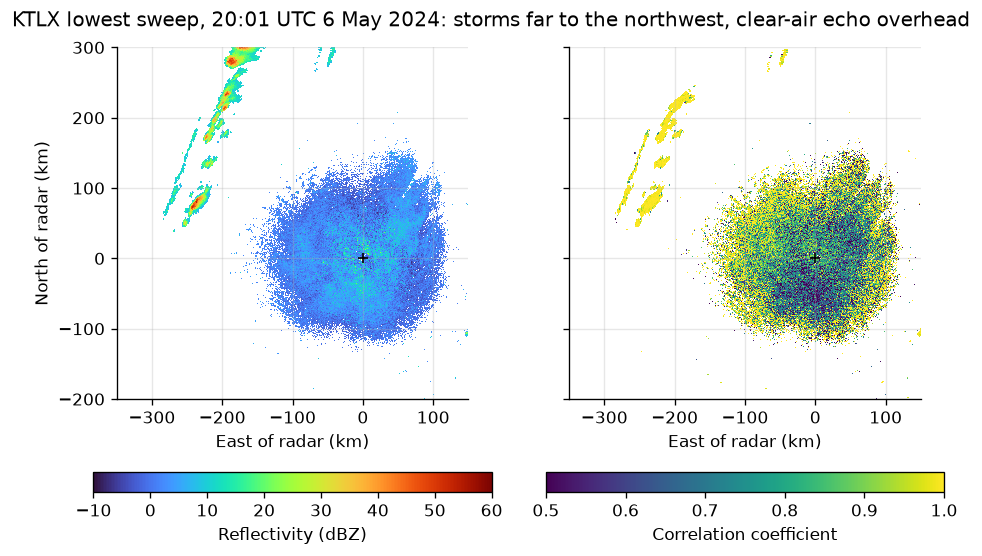

In [5]:
def edges(centres: np.ndarray) -> np.ndarray:
    """Cell edges halfway between centres, extended half a step at each end."""
    middle = (centres[:-1] + centres[1:]) / 2
    return np.concatenate([[2 * centres[0] - middle[0]], middle, [2 * centres[-1] - middle[-1]]])


ordered = sweep.sortby("azimuth")
azimuth = np.deg2rad(edges(ordered.azimuth.values))[:, None]
ground = edges(ordered.range.values)[None, :] * np.cos(np.deg2rad(float(sweep.sweep_fixed_angle)))
east, north = np.sin(azimuth) * ground / 1000, np.cos(azimuth) * ground / 1000
reflectivity = ordered["DBZH"]
correlation = ordered["RHOHV"].where(reflectivity.notnull())

fig, (left, right) = plt.subplots(1, 2, sharey=True, layout="constrained")
panels = [
    (left, reflectivity, "turbo", (-10, 60), "Reflectivity (dBZ)"),
    (right, correlation, "viridis", (0.5, 1.0), "Correlation coefficient"),
]
for ax, values, cmap, (low, high), label in panels:
    mesh = ax.pcolormesh(east, north, values, cmap=cmap, vmin=low, vmax=high, rasterized=True)
    fig.colorbar(mesh, ax=ax, label=label, orientation="horizontal", shrink=0.9)
    ax.plot(0, 0, marker="+", color="black")
    ax.set_aspect("equal")
    ax.set(xlim=(-350, 150), ylim=(-200, 300), xlabel="East of radar (km)")
left.set_ylabel("North of radar (km)")
fig.suptitle(
    f"KTLX lowest sweep, {item.asset.time.start:%H:%M} UTC 6 May 2024: storms far to the "
    "northwest, clear-air echo overhead"
)
plt.show()

In [6]:
near = ordered.range <= 150_000
far = ordered.range >= 200_000
near_echo = reflectivity.where(near)
near_correlation = correlation.where(near)
strong_far = correlation.where(far & (reflectivity >= 40))
print(f"Echo within 150 km: {int(near_echo.count()):,} gates, max {float(near_echo.max()):.1f} dBZ")
print(f"  below 15 dBZ: {float((near_echo < 15).sum() / near_echo.count()):.0%}")
low = float((near_correlation < 0.9).sum() / near_correlation.count())
print(f"  correlation below 0.9: {low:.0%}")
high = float((strong_far >= 0.95).sum() / strong_far.count())
print(f"Echo of 40 dBZ or more beyond 200 km: {int(strong_far.count()):,} gates")
print(f"  correlation of 0.95 or more: {high:.0%}")
print(f"Strongest echo: {float(reflectivity.max()):.1f} dBZ")

Echo within 150 km: 338,736 gates, max 34.0 dBZ
  below 15 dBZ: 98%
  correlation below 0.9: 76%
Echo of 40 dBZ or more beyond 200 km: 221 gates
  correlation of 0.95 or more: 100%
Strongest echo: 65.0 dBZ


At 20:01 UTC the only storms KTLX could see were a line of cells about 250 to 360 km
to the northwest, with correlation near 1. The echo filling the first 150 km
around the radar is weak, 98% of it below 15 dBZ, and three quarters of it has a
correlation coefficient below 0.9: insects and birds in the afternoon
boundary layer, not precipitation. Reflectivity alone would not separate the
two. At 300 km the lowest beam is several kilometres above the ground, so the
distant storms are seen only in their upper parts.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:nexrad-level2
  NEXRAD on AWS was accessed on 2026-09-24 from https://registry.opendata.aws/noaa-nexrad
  homepage: https://registry.opendata.aws/noaa-nexrad/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-24; 1 checksummed asset (9,622,867 bytes) pinned by usdata 0.26.0
  sources: 1


## What was awkward

- The sweep node does not carry the radar's position. `radar["/sweep_0"].to_dataset()`
  has no `latitude` or `longitude`, so xradar's own `georeference()` on it
  fails with `AttributeError: 'Dataset' object has no attribute 'longitude'`,
  and the map above places gates by hand on a flat plane, without beam
  height or earth curvature.
- The whole volume is downloaded even when one sweep is wanted; `sweep=0`
  saves memory, not bytes.
- Moments decode as float64, 11 MB per moment for one sweep, from data stored
  as one or two bytes per gate.
- Selecting one volume by window depends on the volume coverage pattern: five
  minutes holds one clear-air volume but can hold two in precipitation mode,
  and nothing in the manifest says which the radar was in.
- A volume's time is its start, but each ray has its own time and the lowest
  sweep alone spans more than a minute; matching a sweep to an event needs
  the ray times, not the file name.

See the [NEXRAD guide](https://docs.usdata.dev/providers/noaa-nexrad/) and the
[radar and satellite guide](https://docs.usdata.dev/guides/radar-and-satellite/)
for choosing volumes by time, and the
[event-context study](https://usdata.dev/studies/event-context/) for a volume
matched to a tornado report later that evening.